# T1 \ T2 vs time

In [1]:
import numpy as np
from datetime import datetime
from scipy.io import savemat
from scipy.io import loadmat
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
%matplotlib notebook

## Load files

### T1 all-optical

In [9]:
def files_from_folder(mypath):
    return [f for f in listdir(mypath) if isfile(join(mypath, f))]

flag = 0
t0_array = []
t1_array = []
T1_array = []
T1err_array = []

#all-optical
folder_allopt = '.\\Fig_3\\AllOpt_T1vsTime_400avg'
files_allopt = files_from_folder(folder_allopt)
stepSize_averages = 400 #500*91/10 = 4550s
stepSize_averages_T2 = 400 #500*91/10 = 4550s
for file in files_allopt:
    if file.find('.mat') != -1:
        indexStart = file.find('From_') + len('From_')
        indexCenter = file.find('_to_')
        indexEnd = file.find('ms_')
        t0 = int(float(file[indexStart:indexCenter].replace('p','.')))/100 #/100 means /1000 to convert to s and *10 for the beerpong
        t1 = int(float(file[indexCenter+len('_to_'):indexEnd].replace('p','.')))/100
        if file.find('-') == -1:
            if (t0 == 0 or t0%stepSize_averages == 0) and (t1 - t0 == stepSize_averages*91):
                if flag == 0:
                    flag = 1
                    print('Choosen files: ')
                print(file)
                print(str(t0) + ' to ' + str(t1))
                t0_array.append(t0)
                t1_array.append(t1)
                m_dict = loadmat(folder_allopt + '\\' + file)
                popt = np.squeeze(m_dict['popt'])
                pcov = m_dict['pcov']
                T1_array.append(popt[1])
                T1err_array.append(np.sqrt(np.diag(pcov)[1]))
                print('T1: ' + str(popt[1]))
                print('T1 error: ' + str(np.sqrt(np.diag(pcov)[1])))

t0_array_np = np.asarray(t0_array)
t1_array_np = np.asarray(t1_array)
T1_array_np = np.asarray(T1_array)
T1err_array_np = np.asarray(T1err_array)

index_array = np.argsort(t0_array_np)
t0_array_np = t0_array_np[index_array]
t1_array_np = t1_array_np[index_array]
T1_array_np = T1_array_np[index_array]
T1err_array_np = T1err_array_np[index_array]

Choosen files: 
From_0p0_to_3640000p0ms_35p83us_sigma2p39us_opt_dataset0.mat
0.0 to 36400.0
T1: 35826.88956483873
T1 error: 2390.4990608916905
From_10920000p0_to_14560000p0ms_26p52us_sigma1p79us_opt_dataset0.mat
109200.0 to 145600.0
T1: 26519.320688400287
T1 error: 1787.9602821219155
From_14560000p0_to_18200000p0ms_49p27us_sigma3p89us_opt_dataset0.mat
145600.0 to 182000.0
T1: 49269.19889746032
T1 error: 3889.7530248237176
From_3640000p0_to_7280000p0ms_26p26us_sigma1p97us_opt_dataset0.mat
36400.0 to 72800.0
T1: 26261.151828112987
T1 error: 1966.768419322987
From_7280000p0_to_10920000p0ms_21p7us_sigma2p0us_opt_dataset0.mat
72800.0 to 109200.0
T1: 21699.220280634763
T1 error: 1997.2944135478788


### T2 all-optical

In [11]:
flag = 0
t0_array = []
t1_array = []
T1_array = []
T1err_array = []

#all-optical
folder_allopt = '.\\Fig_3\\AllOpt_T2vsTime_400avg'
files_allopt = files_from_folder(folder_allopt)
for file in files_allopt:
    if file.find('.mat') != -1:
        indexStart = file.find('From_') + len('From_')
        indexCenter = file.find('_to_')
        indexEnd = file.find('ms_')
        t0 = int(float(file[indexStart:indexCenter].replace('p','.')))/100 #/100 means /1000 to convert to s and *10 for the beerpong
        t1 = int(float(file[indexCenter+len('_to_'):indexEnd].replace('p','.')))/100
        if file.find('-') == -1:
            if (t0 == 0 or t0%stepSize_averages == 0) and (t1 - t0 == stepSize_averages*85):
                if flag == 0:
                    flag = 1
                    print('Choosen files: ')
                print(file)
                print(str(t0) + ' to ' + str(t1))
                t0_array.append(t0)
                t1_array.append(t1)
                m_dict = loadmat(folder_allopt + '\\' + file)
                popt = np.squeeze(m_dict['popt'])
                pcov = m_dict['pcov']
                T1_array.append(popt[1])
                T1err_array.append(np.sqrt(np.diag(pcov)[1]))
                print('T2: ' + str(popt[1]))
                print('T2 error: ' + str(np.sqrt(np.diag(pcov)[1])))

t0_array_np_T2 = np.asarray(t0_array)
t1_array_np_T2 = np.asarray(t1_array)
T1_array_np_T2 = np.asarray(T1_array)
T1err_array_np_T2 = np.asarray(T1err_array)

index_array = np.argsort(t0_array_np)
t0_array_np_T2 = t0_array_np_T2[index_array]
t1_array_np_T2 = t1_array_np_T2[index_array]
T1_array_np_T2 = T1_array_np_T2[index_array]
T1err_array_np_T2 = T1err_array_np_T2[index_array]

Choosen files: 
From_0p0_to_3400000p0ms_1p49us_sigma0p14us_opt_dataset0.mat
0.0 to 34000.0
T2: 1486.8318267134646
T2 error: 141.87787979975963
From_10200000p0_to_13600000p0ms_1p84us_sigma0p22us_opt_dataset0.mat
102000.0 to 136000.0
T2: 1843.9949735410046
T2 error: 219.8632884507915
From_13600000p0_to_17000000p0ms_1p84us_sigma0p21us_opt_dataset0.mat
136000.0 to 170000.0
T2: 1844.6014179292383
T2 error: 209.8372575738383
From_3400000p0_to_6800000p0ms_1p6us_sigma0p18us_opt_dataset0.mat
34000.0 to 68000.0
T2: 1603.8003762829628
T2 error: 177.84525900371682
From_6800000p0_to_10200000p0ms_1p76us_sigma0p17us_opt_dataset0.mat
68000.0 to 102000.0
T2: 1762.851523575979
T2 error: 167.8841239475856


### T1 mw2opt, mw

In [12]:
flag = 0
t0_array = []
t1_array = []
T1_array = []
T1err_array = []

t0_array_mw = []
t1_array_mw = []
T1_array_mw = []
T1err_array_mw = []

#all-optical
folder_allopt = '.\\Fig_3\\MW_MW2Opt_T1vsTime_400avg'
files_allopt = files_from_folder(folder_allopt)
for file in files_allopt:
    if file.find('.mat') != -1:
        indexStart = file.find('From_') + len('From_')
        indexCenter = file.find('_to_')
        indexEnd = file.find('ms_')
        t0 = int(float(file[indexStart:indexCenter].replace('p','.')))/100 #/100 means /1000 to convert to s and *10 for the beerpong
        t1 = int(float(file[indexCenter+len('_to_'):indexEnd].replace('p','.')))/100
        if file.find('-') == -1:
            if (t0 == 0 or t0%stepSize_averages == 0) and (t1 - t0 == stepSize_averages*91):
                if flag == 0:
                    flag = 1
                    print('Chosen files: ')
                print(file)
                print(str(t0) + ' to ' + str(t1))
                m_dict = loadmat(folder_allopt + '\\' + file)
                popt = np.squeeze(m_dict['popt'])
                pcov = m_dict['pcov']
                
                if file.find('opt') != -1:
                    t0_array.append(t0)
                    t1_array.append(t1)
                    T1_array.append(popt[1])
                    T1err_array.append(np.sqrt(np.diag(pcov)[1]))
                if file.find('mw') != -1:
                    t0_array_mw.append(t0)
                    t1_array_mw.append(t1)
                    T1_array_mw.append(popt[1])
                    T1err_array_mw.append(np.sqrt(np.diag(pcov)[1]))
                
                print('T1: ' + str(popt[1]))
                print('T1 error: ' + str(np.sqrt(np.diag(pcov)[1])))

t0_array_np_mw2opt = np.asarray(t0_array)
t1_array_np_mw2opt = np.asarray(t1_array)
T1_array_np_mw2opt = np.asarray(T1_array)
T1err_array_np_mw2opt = np.asarray(T1err_array)

index_array = np.argsort(t0_array_np)
t0_array_np_mw2opt = t0_array_np_mw2opt[index_array]
t1_array_np_mw2opt = t1_array_np_mw2opt[index_array]
T1_array_np_mw2opt = T1_array_np_mw2opt[index_array]
T1err_array_np_mw2opt = T1err_array_np_mw2opt[index_array]

t0_array_np_mw = np.asarray(t0_array_mw)
t1_array_np_mw = np.asarray(t1_array_mw)
T1_array_np_mw = np.asarray(T1_array_mw)
T1err_array_np_mw = np.asarray(T1err_array_mw)

index_array_mw = np.argsort(t0_array_np_mw)
t0_array_np_mw = t0_array_np_mw[index_array_mw]
t1_array_np_mw = t1_array_np_mw[index_array_mw]
T1_array_np_mw = T1_array_np_mw[index_array_mw]
T1err_array_np_mw = T1err_array_np_mw[index_array_mw]

Chosen files: 
From_0p0_to_3640000p0ms_33p41us_sigma1p8us_mw_dataset0.mat
0.0 to 36400.0
T1: 33413.008364265814
T1 error: 1803.3154199574794
From_0p0_to_3640000p0ms_33p8us_sigma3p47us_opt_dataset0.mat
0.0 to 36400.0
T1: 33803.01389484719
T1 error: 3472.7594876868316
From_10920000p0_to_14560000p0ms_37p0us_sigma2p03us_mw_dataset0.mat
109200.0 to 145600.0
T1: 36999.155702082964
T1 error: 2028.5779340584315
From_10920000p0_to_14560000p0ms_42p29us_sigma3p89us_opt_dataset0.mat
109200.0 to 145600.0
T1: 42288.555662587605
T1 error: 3886.391997966861
From_14560000p0_to_18200000p0ms_29p36us_sigma3p18us_opt_dataset0.mat
145600.0 to 182000.0
T1: 29359.777489828317
T1 error: 3182.926901809738
From_14560000p0_to_18200000p0ms_32p63us_sigma1p81us_mw_dataset0.mat
145600.0 to 182000.0
T1: 32631.806423795497
T1 error: 1808.3075133618104
From_3640000p0_to_7280000p0ms_33p09us_sigma3p28us_opt_dataset0.mat
36400.0 to 72800.0
T1: 33090.86399231616
T1 error: 3275.7593465555988
From_3640000p0_to_7280000p0ms_35p

### T2 mw2opt, mw

In [13]:
dataset = 1

flag = 0
t0_array = []
t1_array = []
T1_array = []
T1err_array = []

t0_array_mw = []
t1_array_mw = []
T1_array_mw = []
T1err_array_mw = []

#all-optical
folder_allopt = '.\\Fig_3\\MW_MW2Opt_T2vsTime_400avg'
files_allopt = files_from_folder(folder_allopt)
for file in files_allopt:
    if file.find('.mat') != -1:
        indexStart = file.find('From_') + len('From_')
        indexCenter = file.find('_to_')
        indexEnd = file.find('ms_')
        t0 = int(float(file[indexStart:indexCenter].replace('p','.')))/100 #/100 means /1000 to convert to s and *10 for the beerpong
        t1 = int(float(file[indexCenter+len('_to_'):indexEnd].replace('p','.')))/100
        if file.find('-') == -1:
            if (t0 == 0 or t0%stepSize_averages == 0) and (t1 - t0 == stepSize_averages*85):
                if flag == 0:
                    flag = 1
                    print('Chosen files: ')
                print(file)
                print(str(t0) + ' to ' + str(t1))
                m_dict = loadmat(folder_allopt + '\\' + file)
                popt = np.squeeze(m_dict['popt'])
                pcov = m_dict['pcov']
                if file.find('dataset' + str(dataset)) != -1:
                    if file.find('opt') != -1:
                        t0_array.append(t0)
                        t1_array.append(t1)
                        T1_array.append(popt[1])
                        T1err_array.append(np.sqrt(np.diag(pcov)[1]))
                    if file.find('mw') != -1:
                        t0_array_mw.append(t0)
                        t1_array_mw.append(t1)
                        T1_array_mw.append(popt[1])
                        T1err_array_mw.append(np.sqrt(np.diag(pcov)[1]))

                    print('T2: ' + str(popt[1]))
                    print('T2 error: ' + str(np.sqrt(np.diag(pcov)[1])))

t0_array_np_mw2opt_T2 = np.asarray(t0_array)
t1_array_np_mw2opt_T2 = np.asarray(t1_array)
T1_array_np_mw2opt_T2 = np.asarray(T1_array)
T1err_array_np_mw2opt_T2 = np.asarray(T1err_array)

index_array = np.argsort(t0_array_np_mw2opt_T2)
t0_array_np_mw2opt_T2 = t0_array_np_mw2opt_T2[index_array]
t1_array_np_mw2opt_T2 = t1_array_np_mw2opt_T2[index_array]
T1_array_np_mw2opt_T2 = T1_array_np_mw2opt_T2[index_array]
T1err_array_np_mw2opt_T2 = T1err_array_np_mw2opt_T2[index_array]

t0_array_np_mw_T2 = np.asarray(t0_array_mw)
t1_array_np_mw_T2 = np.asarray(t1_array_mw)
T1_array_np_mw_T2 = np.asarray(T1_array_mw)
T1err_array_np_mw_T2 = np.asarray(T1err_array_mw)

index_array_mw = np.argsort(t0_array_np_mw_T2)
t0_array_np_mw_T2 = t0_array_np_mw_T2[index_array_mw]
t1_array_np_mw_T2 = t1_array_np_mw_T2[index_array_mw]
T1_array_np_mw_T2 = T1_array_np_mw_T2[index_array_mw]
T1err_array_np_mw_T2 = T1err_array_np_mw_T2[index_array_mw]

Chosen files: 
From_0p0_to_3400000p0ms_1p24us_sigma0p08us_mw_dataset1.mat
0.0 to 34000.0
T2: 1243.0402740436973
T2 error: 75.91024584702603
From_0p0_to_3400000p0ms_1p42us_sigma0p17us_opt_dataset1.mat
0.0 to 34000.0
T2: 1420.111586833225
T2 error: 174.57812915456878
From_10200000p0_to_13600000p0ms_1p3us_sigma0p1us_mw_dataset1.mat
102000.0 to 136000.0
T2: 1303.57232488699
T2 error: 96.62592928920782
From_10200000p0_to_13600000p0ms_1p92us_sigma0p33us_opt_dataset1.mat
102000.0 to 136000.0
T2: 1921.1562646670793
T2 error: 326.49651500150395
From_13600000p0_to_17000000p0ms_1p44us_sigma0p21us_opt_dataset1.mat
136000.0 to 170000.0
T2: 1437.4993270108114
T2 error: 208.24058868639108
From_13600000p0_to_17000000p0ms_1p45us_sigma0p11us_mw_dataset1.mat
136000.0 to 170000.0
T2: 1450.843938777795
T2 error: 108.89804600693742
From_3400000p0_to_6800000p0ms_1p17us_sigma0p16us_opt_dataset1.mat
34000.0 to 68000.0
T2: 1173.1118960375477
T2 error: 164.62577827096075
From_3400000p0_to_6800000p0ms_1p19us_sigm

## Plot T1 and T2 vs time

<IPython.core.display.Javascript object>


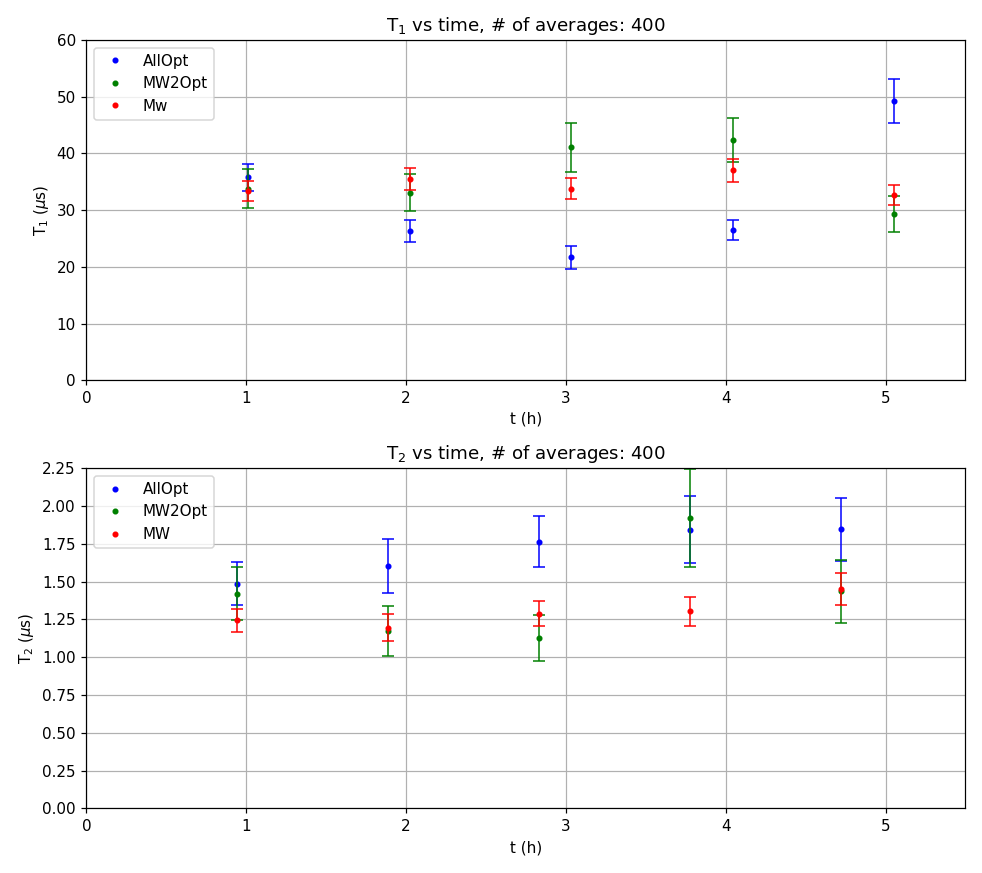

In [14]:
fig, axes = plt.subplots(2,1,figsize=(9,8))
axes[0].plot(t1_array_np/10/3600, T1_array_np*1e-3,'b.',label='AllOpt')
axes[0].errorbar(t1_array_np/10/3600, T1_array_np*1e-3,yerr=T1err_array_np*1e-3,fmt='none',capsize=4.0,ecolor='b',linewidth=1.0)

axes[0].plot(t1_array_np_mw2opt/10/3600, T1_array_np_mw2opt*1e-3,'g.',label='MW2Opt')
axes[0].errorbar(t1_array_np_mw2opt/10/3600, T1_array_np_mw2opt*1e-3,yerr=T1err_array_np_mw2opt*1e-3,fmt='none',capsize=4.0,ecolor='g',linewidth=1.0)

axes[0].plot(t1_array_np_mw/10/3600, T1_array_np_mw*1e-3,'r.',label='Mw')
axes[0].errorbar(t1_array_np_mw/10/3600, T1_array_np_mw*1e-3,yerr=T1err_array_np_mw*1e-3,fmt='none',capsize=4.0,ecolor='r',linewidth=1.0)

axes[0].set_title('T$_1$ vs time, # of averages: ' + str(stepSize_averages))
axes[0].set_xlabel('t (h)')
axes[0].set_ylabel('T$_1$ ($\mu$s)')
axes[0].set_xlim([0,5.5])
axes[0].set_ylim([0,60])
axes[0].legend()
axes[0].grid()

#------------------------------------------------------------------------------------------------------------#

axes[1].plot(t1_array_np_T2/10/3600, T1_array_np_T2*1e-3,'b.',label='AllOpt')
axes[1].errorbar(t1_array_np_T2/10/3600, T1_array_np_T2*1e-3,yerr=T1err_array_np_T2*1e-3,fmt='none',capsize=4.0,ecolor='b',linewidth=1.0)

axes[1].plot(t1_array_np_mw2opt_T2/10/3600, T1_array_np_mw2opt_T2*1e-3,'g.',label='MW2Opt')
axes[1].errorbar(t1_array_np_mw2opt_T2/10/3600, T1_array_np_mw2opt_T2*1e-3,yerr=T1err_array_np_mw2opt_T2*1e-3,fmt='none',capsize=4.0,ecolor='g',linewidth=1.0)

axes[1].plot(t1_array_np_mw_T2/10/3600, T1_array_np_mw_T2*1e-3,'r.',label='MW')
axes[1].errorbar(t1_array_np_mw_T2/10/3600, T1_array_np_mw_T2*1e-3,yerr=T1err_array_np_mw_T2*1e-3,fmt='none',capsize=4.0,ecolor='r',linewidth=1.0)

axes[1].set_title('T$_2$ vs time, # of averages: ' + str(stepSize_averages_T2))
axes[1].set_xlabel('t (h)')
axes[1].set_ylabel('T$_2$ ($\mu$s)')
axes[1].set_xlim([0,5.5])
axes[1].set_ylim([0,2.25])
axes[1].legend()
axes[1].grid()

#------------------------------------------------------------------------------------------------------------#

plt.tight_layout()
plt.show()

## Uncertainties

In [15]:
from uncertainties import ufloat, unumpy
from uncertainties.umath import *

T1_allopt_up = np.mean(unumpy.uarray(T1_array_np, T1err_array_np))
print('T1_allopt_up: ' + str(np.round(T1_allopt_up.n*1e-3,2)) + ' +/- ' + str(np.round(T1_allopt_up.s*1e-3,2)) + ' us')
T1_mw2opt_up = np.mean(unumpy.uarray(T1_array_np_mw2opt, T1err_array_np_mw2opt))
print('T1_mw2opt_up: ' + str(np.round(T1_mw2opt_up.n*1e-3,2)) + ' +/- ' + str(np.round(T1_mw2opt_up.s*1e-3,2)) + ' us')
T1_mw_up = np.mean(unumpy.uarray(T1_array_np_mw, T1err_array_np_mw))
print('T1_mw_up: ' + str(np.round(T1_mw_up.n*1e-3,2)) + ' +/- ' + str(np.round(T1_mw_up.s*1e-3,2)) + ' us')


#Below values for the standard deviation still need to be adjusted by a student-t distribution, see paper


T2_allopt_up = np.mean(unumpy.uarray(T1_array_np_T2, T1err_array_np_T2))
print('T2_allopt_up: ' + str(np.round(T2_allopt_up.n*1e-3,2)) + ' +/- ' + str(np.round(T2_allopt_up.s*1e-3,2)) + ' us')
T2_mw2opt_up = np.mean(unumpy.uarray(T1_array_np_mw2opt_T2, T1err_array_np_mw2opt_T2))
print('T2_mw2opt_up: ' + str(np.round(T2_mw2opt_up.n*1e-3,2)) + ' +/- ' + str(np.round(T2_mw2opt_up.s*1e-3,2)) + ' us')
T2_mw_up = np.mean(unumpy.uarray(T1_array_np_mw_T2, T1err_array_np_mw_T2))
print('T2_mw_up: ' + str(np.round(T2_mw_up.n*1e-3,2)) + ' +/- ' + str(np.round(T2_mw_up.s*1e-3,2)) + ' us')


T1_allopt_up: 31.92 +/- 1.13 us
T1_mw2opt_up: 35.93 +/- 1.63 us
T1_mw_up: 34.47 +/- 0.84 us
T2_allopt_up: 1.71 +/- 0.08 us
T2_mw2opt_up: 1.42 +/- 0.1 us
T2_mw_up: 1.3 +/- 0.04 us
